<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/feat%2Fweekly-updates/notebooks/4_model_optimisation/week7_model_optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Model Optimisation and Trade-offs
### Mercer General Hospital Emergency Department

Author: Mya Symister

Random seed: random_state = 42, matching Week 6, so all comparisons below are on the same test patients.

This notebook builds on the Week 6 baseline (logistic regression and decision tree) by training two more complex classifiers, a tuned random forest and a gradient boosting model, on the identical train-test split. The aim is not to find the single best model, but to produce an honest six-axis benchmark that can support a cost-benefit recommendation to the ED Board and IT Governance.

In [15]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, time, os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

RANDOM_STATE = 42
pd.set_option("display.width", 120)
print("Libraries loaded.")

Libraries loaded.


## 1. Loading and cleaning the raw data

The raw triage export is cleaned using the same steps established in Week 5 and Week 6: vitals are coerced to numeric, rows with an invalid ESI label are dropped, physiologically impossible readings are treated as missing, gender is mapped to a binary value, and remaining gaps are filled with the column median.

In [16]:
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/CariSurg/yaleemmlc_admissionprediction_triage.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Loaded", df_raw.shape[0], "patients and", df_raw.shape[1], "columns.")
df_raw.head()

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

df = df_raw.copy()
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 patients and 226 columns.
Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


## 2. Feature and target selection

The feature set excludes disposition and previousdispo, since these are only known after triage and would leak the outcome into the model. Administrative fields and demographic variables are also excluded from the base feature set, consistent with the fairness considerations raised in Week 4. The split below uses the same random_state and test proportion as Week 6, so the test set contains the same patients the baseline was scored on.

In [17]:
TARGET = "esi"
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]
X = df[FEATURES]
y = df[TARGET]
print("Model will use", len(FEATURES), "features:", FEATURES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

Model will use 208 features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess', 'cc_addictionproblem', 'cc_agitation', 'cc_alcoholintoxication', 'cc_alcoholproblem', 'cc_allergicreaction', 'cc_alteredmentalstatus', 'cc_animalbite', 'cc_ankleinjury', 'cc_anklepain', 'cc_anxiety', 'cc_arminjury', 'cc_armpain', 'cc_armswelling', 'cc_assaultvictim', 'cc_asthma', 'cc_backpain', 'cc_bleeding/bruising', 'cc_blurredvision', 'cc_bodyfluidexposure', 'cc_breastpain', 'cc_breathingdifficulty', 'cc_breathingproblem', 'cc_burn', 'cc_cardiacarrest', 'cc_cellulitis', 'cc_chestpain', 'cc_chesttightness', 'cc_chills', 'cc_coldlikesymptoms', 'cc_confusion', 'cc_conjunctivitis', 'cc_constipation', 'cc_cough', 'cc_cyst', 'cc_decreasedbloodsugar-symptomatic', 'cc_dehydr

## 3. Clinical feature engineering

A small number of derived features are added: shock index, pulse pressure, and a respiratory ratio, along with three binary red flags for tachypnoea, hypoxia, and fever. These are constructed to include signal from vitals other than blood pressure, which is frequently missing or unreliable at triage.

In [18]:
def add_clinical_features(data):
    out = data.copy()
    out["shock_index"]    = out["triage_vital_hr"] / out["triage_vital_sbp"]
    out["pulse_pressure"] = out["triage_vital_sbp"] - out["triage_vital_dbp"]
    out["spo2_rr_ratio"]  = out["triage_vital_o2"] / out["triage_vital_rr"]
    out["is_tachypneic"]  = (out["triage_vital_rr"]   > 20).astype(int)
    out["is_hypoxic"]     = (out["triage_vital_o2"]   < 92).astype(int)
    out["is_febrile"]     = (out["triage_vital_temp"] >= 100.4).astype(int)
    out["red_flag_count"] = out[["is_tachypneic", "is_hypoxic", "is_febrile"]].sum(axis=1)
    return out

X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)
print("Features after engineering:", X_train_fe.shape[1])
X_train_fe.head()

Features after engineering: 215


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,shock_index,pulse_pressure,spo2_rr_ratio,is_tachypneic,is_hypoxic,is_febrile,red_flag_count
35369,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0.0,0.0,0.0,0.866667,49.0,4.454545,1,0,0,1
52043,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0.0,0.0,0.0,0.678261,39.0,5.333333,0,0,0,0
13610,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0.0,0.0,0.0,0.806723,41.0,5.222222,0,0,0,0
54796,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0.0,0.0,0.0,0.695312,35.0,6.125000,0,0,0,0
11096,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0.0,0.0,0.0,0.787611,35.0,5.444444,0,0,0,0


## 4. Re-establishing the Week 6 baseline

Both Week 6 models, logistic regression and a decision tree, are retrained here on the identical split so that training time and inference time can be measured under the same conditions as the new models. This gives a fair basis for the benchmark in Section 9.

In [19]:
def time_fit_predict(model, X_tr, y_tr, X_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = model.predict(X_te)
    infer_ms_per_pred = (time.perf_counter() - t0) / len(X_te) * 1000
    return preds, train_time, infer_ms_per_pred

# --- Baseline 1: Logistic Regression ---
baseline_logreg = make_pipeline(StandardScaler(),
                                 LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
preds_logreg, train_t_logreg, infer_t_logreg = time_fit_predict(
    baseline_logreg, X_train_fe, y_train, X_test_fe)

# --- Baseline 2: Decision Tree ---
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
preds_tree, train_t_tree, infer_t_tree = time_fit_predict(
    baseline_tree, X_train_fe, y_train, X_test_fe)

print("LogReg  macro-F1:", round(f1_score(y_test, preds_logreg, average='macro'), 3))
print("DecTree macro-F1:", round(f1_score(y_test, preds_tree, average='macro'), 3))

LogReg  macro-F1: 0.481
DecTree macro-F1: 0.366


## 5. Random forest with hyperparameter tuning

A random forest is trained with class_weight set to balanced, to account for the rarity of ESI 1 in the dataset. Hyperparameters are tuned using RandomizedSearchCV with three-fold cross-validation, scoring on macro F1.

In [20]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=8, cv=3, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.perf_counter()
rf_search.fit(X_train_fe, y_train)
rf_train_time = time.perf_counter() - t0

rf_tuned = rf_search.best_estimator_
print("Best params:", rf_search.best_params_)
print("Best CV macro-F1:", round(rf_search.best_score_, 3))

t0 = time.perf_counter()
preds_rf = rf_tuned.predict(X_test_fe)
rf_infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000

rf_f1 = f1_score(y_test, preds_rf, average="macro")
print("Tuned Random Forest test macro-F1:", round(rf_f1, 3))

pd.Series(rf_tuned.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'n_estimators': 200, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None}
Best CV macro-F1: 0.464
Tuned Random Forest test macro-F1: 0.475


,0
triage_vital_sbp,0.090277
cc_strokealert,0.084695
shock_index,0.074918
triage_glucose,0.071300
triage_vital_dbp,0.067241
triage_vital_temp,0.059270
spo2_rr_ratio,0.057613
triage_vital_hr,0.054231
pulse_pressure,0.054222
triage_vital_o2_device,0.046676


## 6. Gradient boosting

A histogram-based gradient boosting classifier is trained as the second complex model. Trees are built sequentially, with each tree correcting the errors of the previous one, which typically performs well on tabular clinical data.

In [21]:
hgb = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.1, max_iter=300,
    class_weight="balanced", random_state=RANDOM_STATE)

t0 = time.perf_counter()
hgb.fit(X_train_fe, y_train)
hgb_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
preds_hgb = hgb.predict(X_test_fe)
hgb_infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000

hgb_f1 = f1_score(y_test, preds_hgb, average="macro")
print("Gradient Boosting test macro-F1:", round(hgb_f1, 3))

# Gradient boosting has no built-in feature_importances_ in the Hist implementation by default;
# use permutation_importance if you want a ranked list here:
# from sklearn.inspection import permutation_importance
# perm = permutation_importance(hgb, X_test_fe, y_test, scoring="f1_macro", random_state=RANDOM_STATE)
# pd.Series(perm.importances_mean, index=X_test_fe.columns).sort_values(ascending=False).head(10)

Gradient Boosting test macro-F1: 0.416


## 7. Per-class performance

Aggregate accuracy can conceal how a model performs on the rarest and most clinically significant class. The classification reports below show precision, recall, and F1 for each ESI level individually, for all four models.

In [22]:
def per_class_report(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, digits=3))
    print()

for name, preds in [("Logistic Regression (baseline)", preds_logreg),
                    ("Decision Tree (baseline)", preds_tree),
                    ("Random Forest (tuned)", preds_rf),
                    ("Gradient Boosting", preds_hgb)]:
    per_class_report(name, y_test, preds)

--- Logistic Regression (baseline) ---
              precision    recall  f1-score   support

           1      0.375     0.188     0.250        16
           2      0.726     0.613     0.664      3585
           3      0.663     0.764     0.710      5402
           4      0.611     0.586     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.671     11025
   macro avg      0.571     0.452     0.481     11025
weighted avg      0.670     0.671     0.665     11025


--- Decision Tree (baseline) ---
              precision    recall  f1-score   support

           1      0.045     0.062     0.053        16
           2      0.544     0.549     0.546      3585
           3      0.599     0.584     0.591      5402
           4      0.430     0.448     0.439      1779
           5      0.195     0.210     0.202       243

    accuracy                          0.542     11025
   macro avg      0.363     0.371     0.366     11025
weig

## 8. Error analysis: confusion matrices

Since ESI 1 patients are the most clinically urgent and the rarest in this dataset, error analysis begins with how many true ESI 1 cases each model failed to identify, rather than with the overall accuracy figure.

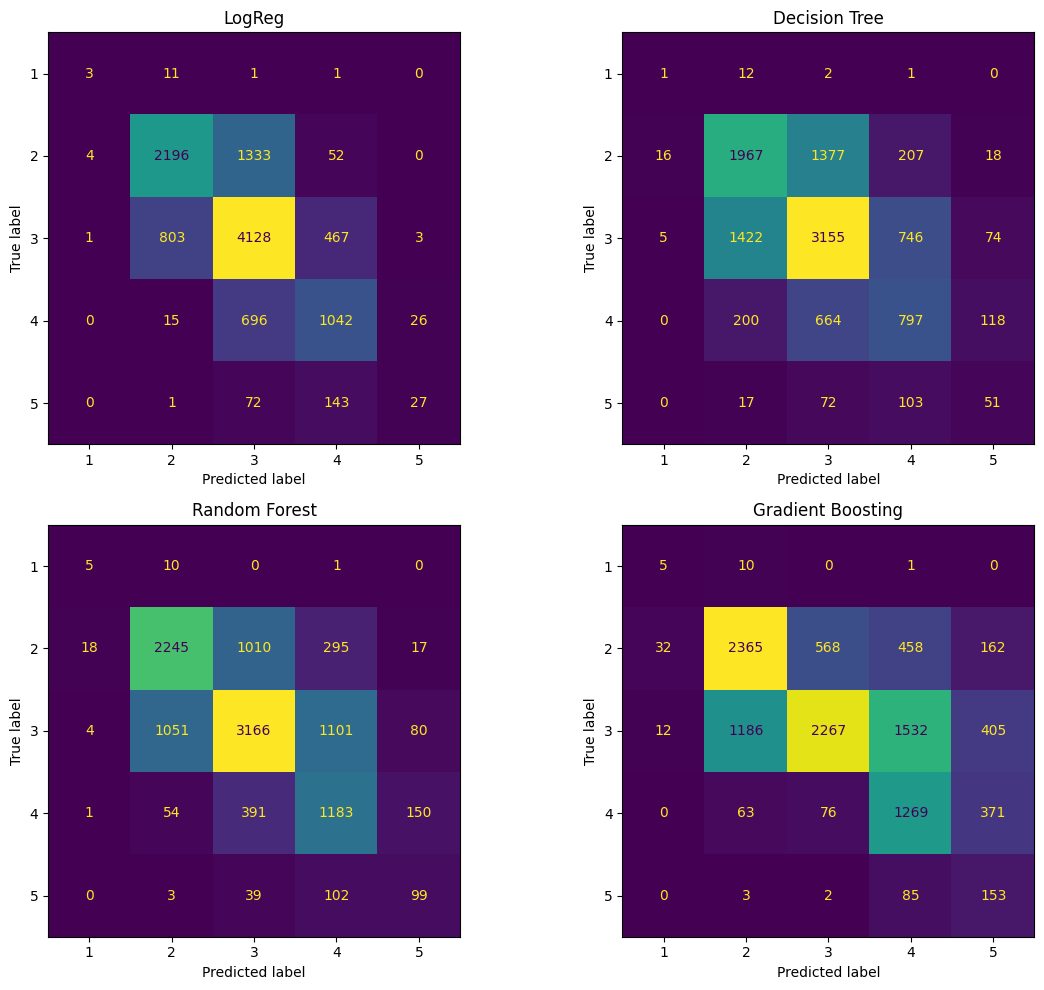

LogReg: missed 13 of 16 true ESI-1 patients (recall = 0.19)
Decision Tree: missed 15 of 16 true ESI-1 patients (recall = 0.06)
Random Forest: missed 11 of 16 true ESI-1 patients (recall = 0.31)
Gradient Boosting: missed 11 of 16 true ESI-1 patients (recall = 0.31)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_preds = [("LogReg", preds_logreg), ("Decision Tree", preds_tree),
                ("Random Forest", preds_rf), ("Gradient Boosting", preds_hgb)]

for ax, (name, preds) in zip(axes.ravel(), models_preds):
    cm = confusion_matrix(y_test, preds, labels=sorted(y_test.unique()))
    ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique())).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("week7_confusion_matrices.png", dpi=150)
plt.show()

# Explicit ESI-1 miss count for each model — the number the memo should lead its error analysis with
esi1_mask = (y_test == 1)
for name, preds in models_preds:
    preds_arr = np.array(preds)
    missed = int(((preds_arr[esi1_mask.values] != 1)).sum())
    total_esi1 = int(esi1_mask.sum())
    print(f"{name}: missed {missed} of {total_esi1} true ESI-1 patients "
          f"(recall = {(total_esi1 - missed)/total_esi1:.2f})")

## 9. Six-axis benchmark

The table below compares all four models on accuracy, macro precision, macro recall, macro F1, training time, and inference time per prediction. This is the quantitative basis for the cost-benefit memo.

In [24]:
def summarise(name, y_true, y_pred, train_time, infer_time_ms):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision (macro)": round(prec, 3),
        "Recall (macro)": round(rec, 3),
        "F1 (macro)": round(f1, 3),
        "Train time (s)": round(train_time, 2),
        "Inference (ms/pred)": round(infer_time_ms, 3),
    }

rows = [
    summarise("Logistic Regression (baseline)", y_test, preds_logreg, train_t_logreg, infer_t_logreg),
    summarise("Decision Tree (baseline)", y_test, preds_tree, train_t_tree, infer_t_tree),
    summarise("Random Forest (tuned)", y_test, preds_rf, rf_train_time, rf_infer_time),
    summarise("Gradient Boosting", y_test, preds_hgb, hgb_train_time, hgb_infer_time),
]

benchmark_table = pd.DataFrame(rows).set_index("Model")
benchmark_table.to_csv("week7_benchmark_table.csv")
benchmark_table.to_markdown("week7_benchmark_table.md")
benchmark_table

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Train time (s),Inference (ms/pred)
Model,,,,,,
Logistic Regression (baseline),0.671,0.571,0.452,0.481,14.36,0.006
Decision Tree (baseline),0.542,0.363,0.371,0.366,5.14,0.002
Random Forest (tuned),0.608,0.452,0.519,0.475,1724.88,0.060
Gradient Boosting,0.550,0.410,0.547,0.416,12.79,0.019


## 10. Interpretability

Beyond the six quantitative axes, a model's clinical usefulness depends on whether a single prediction can be explained. The table below records a rating for each model, based on the feature importance results above.

| Model | Method | Rating | One-line reason |
|--------|--------|--------|-----------------|
| Logistic Regression | Read the coefficients directly | **High** | Each ESI class has one linear weight per feature, so a prediction can be traced to a small number of contributing vitals in seconds. |
| Decision Tree | Trace the branches | **High** | A single tree means one prediction follows one path of yes/no splits, which can be read aloud to Dr. Reyes directly from the tree. |
| Random Forest (tuned) | `feature_importances_` (global, not per-patient) | **Medium** | The importances show that `triage_vital_sbp`, `cc_strokealert`, and `shock_index` drive the model overall, but with 200 trees voting, no single path explains why one patient was flagged; only the general tendency is visible. |
| Gradient Boosting | Would need permutation importance or SHAP for a per-patient story | **Low** | The Hist implementation has no built-in per-tree importances, and because each tree corrects the last one's residual errors, no single tree's logic represents the final prediction. |

## 11. Summary

The saved models and benchmark table below are the artefacts this notebook produces for the cost-benefit memo and decision journal.

In [25]:
joblib.dump(rf_tuned, "w7_random_forest.joblib")
joblib.dump(hgb, "w7_gradient_boosting.joblib")
print("Saved: w7_random_forest.joblib, w7_gradient_boosting.joblib")
print()
print("Benchmark table (also saved to week7_benchmark_table.csv / .md):")
print(benchmark_table)

Saved: w7_random_forest.joblib, w7_gradient_boosting.joblib

Benchmark table (also saved to week7_benchmark_table.csv / .md):
                                Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Train time (s)  \
Model                                                                                                     
Logistic Regression (baseline)     0.671              0.571           0.452       0.481           14.36   
Decision Tree (baseline)           0.542              0.363           0.371       0.366            5.14   
Random Forest (tuned)              0.608              0.452           0.519       0.475         1724.88   
Gradient Boosting                  0.550              0.410           0.547       0.416           12.79   

                                Inference (ms/pred)  
Model                                                
Logistic Regression (baseline)                0.006  
Decision Tree (baseline)                      0.002  
Random Forest (